In [27]:
#from cellpose import models
#import pyclesperanto as cle
# from bioio import BioImage
# from skimage.segmentation import relabel_sequential
# from skimage.morphology import remove_small_objects
# from skimage.transform import rescale, resize
# from skimage.io import imsave, imread
# from skimage.measure import label, regionprops, regionprops_table, marching_cubes, mesh_surface_area
# from scipy import ndimage
# import numpy as np
# from glob import glob
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
#from tqdm import tqdm
#from joblib import Parallel, delayed

#cle.select_device("NVIDIA")

In [11]:
def read_imgs(path):
    files = sorted(glob(f"{path}/*.czi"))
    names = list(map(os.path.basename,files))
    names = [name[0:-4] for name in names]
    img_data = [BioImage(f).get_image_data("ZYX", C=1) for f in files]
    pixel_spacing = get_pixel_spacing(BioImage(files[0]))
    return img_data, pixel_spacing, names

def get_pixel_spacing(img):
    ''' 
    Use one image from dataset read in with BioImage without .get_image_data to access pixel spacing
    '''
    if img.dims['Z'][0] > 1:
        pixel_spacing = (img.physical_pixel_sizes[0],img.physical_pixel_sizes[1],img.physical_pixel_sizes[2])
    else:
        pixel_spacing = (img.physical_pixel_sizes[0],img.physical_pixel_sizes[1])
    return pixel_spacing

def normalize_images(input_image,tophat_radius=10):
    input_gpu = cle.push(input_image)
    #normalizing the image stack
    equalized_intensities_stack = cle.create_like(input_gpu)
    a_slice = cle.create([input_gpu.shape[1], input_gpu.shape[2]])
    num_slices = input_gpu.shape[0]
    mean_intensity_stack = cle.mean_of_all_pixels(input_gpu)
    corrected_slice = None
    for z in range(0, num_slices):
        # get a single slice out of the stack
        cle.copy_slice(input_gpu, a_slice, z)
        # measure its intensity
        mean_intensity_slice = cle.mean_of_all_pixels(a_slice)
        # correct the intensity
        correction_factor = mean_intensity_slice/mean_intensity_stack
        corrected_slice = cle.multiply_image_and_scalar(a_slice, corrected_slice, correction_factor)
        # copy slice back in a stack
        cle.copy_slice(corrected_slice, equalized_intensities_stack, z)
    #background subtraction (increase the signal to noise ratio for improved segmentation results)
    background_subtracted_top_hat = cle.top_hat_sphere(equalized_intensities_stack,radius_x=tophat_radius,radius_y=tophat_radius,radius_z=tophat_radius)
    #pull data off gpu
    input_pull = cle.pull(input_gpu)
    background_subtracted_top_hat_pull = cle.pull(background_subtracted_top_hat)
    equalized_intensities_stack_pull = cle.pull(equalized_intensities_stack)
    return background_subtracted_top_hat_pull

def down_size(img, scale=None):
   scale == 1 if scale == None else scale == scale
   if scale == None:
       print('no scaling provided, using scaling of 1 (no scaling applied)')
   return rescale(img, scale, anti_aliasing=True, channel_axis=None,preserve_range=True)

def run_cpsam(imgs):
    '''
    Give function list of all resized images for more efficient processing
    '''
    #io.logger_setup()
    model = models.CellposeModel(gpu=True)
    masks, _, _ = model.eval(imgs, batch_size=32, z_axis=0, do_3D=False,normalize=True,stitch_threshold=0.6,cellprob_threshold=-0.5)
    return masks

def up_size_masks(masks, img):
    if masks.shape == img.shape:
        print('masks and image are the same size, no resizing applied')
        return masks
    else:
        return resize(masks,img.shape,preserve_range=True,order=0).astype(np.uint16)

def clear_xy_borders(mask_img,border):
    bool_arr = np.zeros((mask_img.shape[0],mask_img.shape[1]-border*2,mask_img.shape[2]-border*2))
    xy_boarder = np.pad(bool_arr,pad_width=((0,0),(border,border),(border,border)),mode='constant',constant_values=1).astype(np.bool)
    labels, number = label(mask_img,background=0,return_num=True)
    indices = np.arange(number+1)
    border_indices = np.unique(labels[xy_boarder])
    label_mask = np.isin(indices, border_indices)
    mask = label_mask[labels.reshape(-1)].reshape(labels.shape)
    labels[mask] = 0
    return labels
     

def process_masks(mask_img, border, save_path, name):
    cleared_borders = clear_xy_borders(mask_img, border)
    rmv_small_objs = remove_small_objects(cleared_borders,max_size=200)
    seq_lables, _, _ = relabel_sequential(rmv_small_objs)
    imsave(os.path.join(save_path,f'{name}_cell_masks.tif'),seq_lables,check_contrast=False)
    return seq_lables

def _label_sa_solidity_pre(label_val, submask, pixel_spacing):
    m = submask.astype(np.uint8)

    # surface area
    padded = np.pad(m, 1, mode='constant')
    verts, faces, _, _ = marching_cubes(padded, level=0.5, spacing=pixel_spacing)
    surface_area = mesh_surface_area(verts, faces)

    # solidity on the same small crop — convex hull is cheap here
    sub_props = regionprops(m)[0]
    solidity = sub_props.solidity

    return label_val, surface_area, solidity


def measure_objects(mask_img, pixel_spacing, name, n_jobs=15):
    # 1. Standard descriptors — one fast pass.
    #    Pass spacing so 'area' is volume in physical units (e.g. µm³).
    #print('collecting regions properties')
    props_df = pd.DataFrame(regionprops_table(
        mask_img,
        spacing=pixel_spacing,
        properties=[
            'label', 'area', 'centroid', 'equivalent_diameter_area', 
            'extent', 'axis_major_length', 'axis_minor_length'
        ],
    ))

    # 2. Pre-crop each object in the main process so workers receive only
    #    a tiny bool array, not the full label volume.
    #print('finding objects with ndimage')
    objects = ndimage.find_objects(mask_img)
    #print(f'extracting subregions for {len(objects)}')
    tasks = []
    for idx, sl in enumerate(objects):
        if sl is None:
            continue
        label_val = idx + 1
        padded_sl = tuple(slice(max(0, s.start - 1), s.stop + 1) for s in sl)
        submask = (mask_img[padded_sl] == label_val)   # small bool array
        tasks.append((label_val, submask))

    # 3. Parallelize only the costly surface-area extraction.
    #print('Extracting suface areas for objects')
    results = Parallel(n_jobs=n_jobs)(
        delayed(_label_sa_solidity_pre)(label_val, submask, pixel_spacing)
        for label_val, submask in tasks
    )
    sa_df = pd.DataFrame(results, columns=['label', 'surface_area', 'solidity'])
    # 4. Merge on label — order-independent, gap-safe.
    #print(props_df.columns)
    df = props_df.merge(sa_df, on='label', how='left')
    # 5. Sphericity as a vectorized op, now that V and A are aligned columns.
    #    'area' is volume because spacing was passed to regionprops.
    df['sphericity'] = (np.pi**(1/3) * (6 * df['area'])**(2/3)) / df['surface_area']
    df['Image'] = name
    return df

def assign_condition(r):
    if 'WT_ctrl' in r['Image']:
        return 'WT-ctrl'
    elif 'DKO_ctrl' in r['Image']:
        return 'DKO-ctrl'
    else:
        return 'Unknown'

def merge_dfs_save(dfs, save_loc):
    all_data = pd.concat(dfs,ignore_index=True)
    all_data['group'] = all_data.apply(lambda x: assign_condition(x), axis=0)
    all_data.to_csv(os.path.join(save_loc,'Zebrafish_desmosome_df.tsv'), sep='\t',index=False)

    return all_data

In [ ]:
# full run
path = r"E:\KristinG\20260625_zebrafish\fin"
save_img_path = r"E:\KristinG\20260625_zebrafish\fin_outputs\Cell_Masks"
save_df_path = r"E:\KristinG\20260625_zebrafish\fin_outputs"
scale = [0.5,0.2,0.2]
print('reading in image data')
imgs, pixel_spacing, names = read_imgs(path)
print('normalizing images')
norm_imgs = [normalize_images(i) for i  in tqdm(imgs)]
del(imgs)
print('rescaling')
rescaled_imgs = [down_size(i,scale) for i in tqdm(norm_imgs)]
print('running cpsam')
masks = tqdm(run_cpsam(rescaled_imgs))
del(rescaled_imgs)
print('resizing masks')
resized_masks = [up_size_masks(m, i) for m, i in tqdm(zip(masks,norm_imgs))]
del(norm_imgs)
del(masks)
print('clearing objects from XY border and saving')
cleared_borders = [clear_xy_borders(m, border = 6, name = n, save_path = save_img_path) for m,n in tqdm(zip(resized_masks, names))]
del(resized_masks)
print('getting object measurements')
dfs = [measure_objects(m,pixel_spacing,n) for m, n in tqdm(zip(cleared_borders,names))]
print('saving data frame')
merge_dfs_save(dfs,save_df_path)
del(cleared_borders,dfs)

In [4]:
masks_path = r"E:\KristinG\20260625_zebrafish\fin_outputs\Cell_Masks"
save_new_masks_path = r"E:\KristinG\20260625_zebrafish\fin_outputs\Filtered_Cell_Masks"
save_df_path = r"E:\KristinG\20260625_zebrafish\fin_outputs"
pixel_spacing = get_pixel_spacing(BioImage(r"E:\KristinG\20260625_zebrafish\fin\DKO_ctrl_1_skin_1_ventral_fin_Out.czi"))
mask_files = sorted(glob(rf'{masks_path}\*.tif'))
masks = list(map(imread,mask_files))

In [5]:
names = [os.path.basename(f)[:-4] for f in mask_files]

In [7]:
processed_masks = [process_masks(m, border = 6, name = n, save_path=save_new_masks_path) for m,n in tqdm(zip(masks,names))]

106it [07:14,  4.10s/it]


In [ ]:
dfs = [measure_objects(m,pixel_spacing,n) for m, n in tqdm(zip(processed_masks,names))]
print('saving data frame')
all_data = merge_dfs_save(dfs,save_df_path)

100it [40:38, 23.10s/it]

In [2]:
df = pd.read_table('/home/gkristin/Zebrafish_desmosomes/Zebrafish_desmosome_df.tsv',sep='\t')

In [7]:
df.columns

Index(['label', 'area', 'centroid-0', 'centroid-1', 'centroid-2',
       'equivalent_diameter_area', 'extent', 'axis_major_length',
       'axis_minor_length', 'surface_area', 'solidity', 'sphericity', 'Image'],
      dtype='str')

In [9]:
Image_col = df['Image']

In [10]:
def assign_condition(r):
    if 'WT_ctrl' in r['Image']:
        return 'WT-ctrl'
    elif 'DKO_ctrl' in r['Image']:
        return 'DKO-ctrl'
    else:
        return 'Unknown'
df['groups'] = df.apply(assign_condition,axis=1)

In [11]:
df.head()

,label,area,centroid-0,centroid-1,centroid-2,equivalent_diameter_area,extent,axis_major_length,axis_minor_length,surface_area,solidity,sphericity,Image,groups
0,1,356.662167,1.903198,19.538876,58.869930,8.798720,0.611303,16.788625,5.549059,368.569503,0.895139,0.659887,DKO_ctrl_10_skin_1_dorsal_fin_Out_cell_masks,DKO-ctrl
1,2,195.827718,0.240758,25.223210,44.269483,7.204854,0.734848,21.707451,1.076701,463.861361,0.909944,0.351570,DKO_ctrl_10_skin_1_dorsal_fin_Out_cell_masks,DKO-ctrl
2,3,39.659038,0.240758,20.416894,70.379282,4.231047,0.764045,10.004798,1.076701,107.647402,0.946467,0.522447,DKO_ctrl_10_skin_1_dorsal_fin_Out_cell_masks,DKO-ctrl
3,4,31.628532,0.240758,20.268196,86.376868,3.923679,0.557312,12.433263,1.076701,93.444250,0.874690,0.517588,DKO_ctrl_10_skin_1_dorsal_fin_Out_cell_masks,DKO-ctrl
4,5,274.786890,0.240758,30.308456,31.459664,8.066141,0.742424,28.220889,1.076701,639.831597,0.939129,0.319459,DKO_ctrl_10_skin_1_dorsal_fin_Out_cell_masks,DKO-ctrl


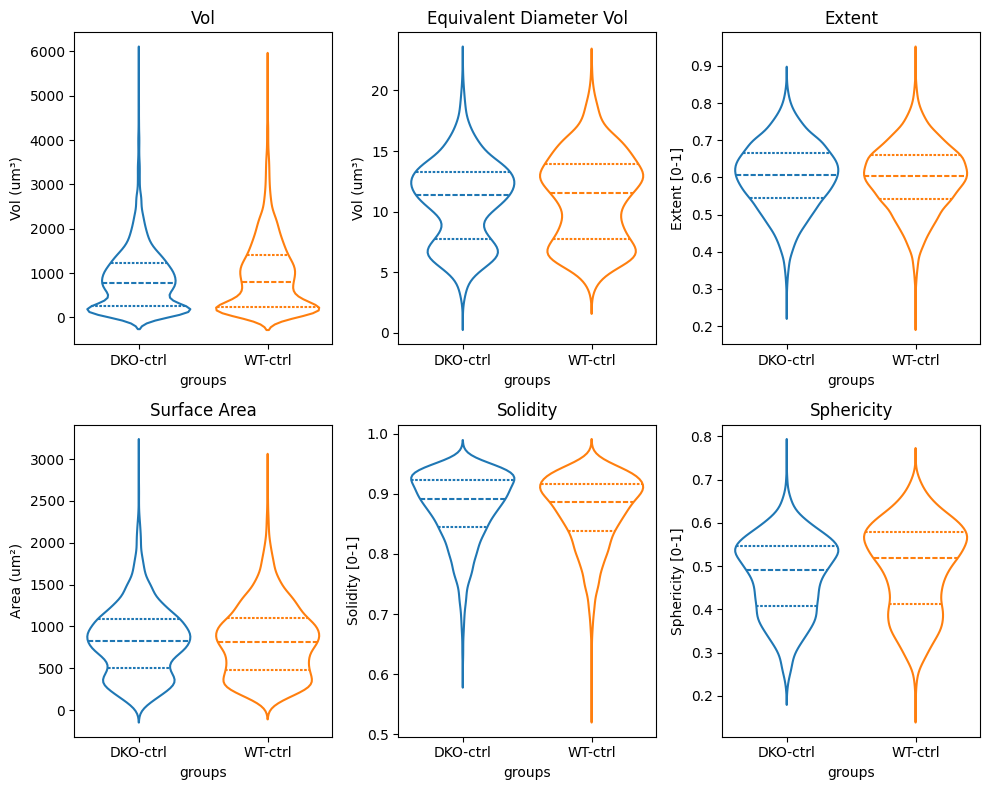

In [35]:
# create plots for easy vis
fig, axs = plt.subplots(2,3,figsize=(10,8))
sns.violinplot(data=df, x='groups', y='area', hue='groups', fill=False, inner='quart',ax=axs[0,0])
axs[0,0].set_title('Vol')
axs[0,0].set_ylabel('Vol (um³)')
sns.violinplot(data=df, x='groups', y='equivalent_diameter_area',hue='groups',fill=False, inner='quart',ax=axs[0,1])
axs[0,1].set_title('Equivalent Diameter Vol')
axs[0,1].set_ylabel('Vol (um³)')
sns.violinplot(data=df, x='groups', y='extent',hue='groups',fill=False, inner='quart',ax=axs[0,2])
axs[0,2].set_title('Extent')
axs[0,2].set_ylabel('Extent [0-1]')
sns.violinplot(data=df, x='groups', y='surface_area',hue='groups',fill=False, inner='quart',ax=axs[1,0])
axs[1,0].set_title('Surface Area')
axs[1,0].set_ylabel('Area (um²)')
sns.violinplot(data=df, x='groups', y='solidity',hue='groups',fill=False, inner='quart',ax=axs[1,1])
axs[1,1].set_title('Solidity')
axs[1,1].set_ylabel('Solidity [0-1]')
sns.violinplot(data=df, x='groups', y='sphericity',hue='groups',fill=False, inner='quart',ax=axs[1,2])
axs[1,2].set_title('Sphericity')
axs[1,2].set_ylabel('Sphericity [0-1]')
plt.tight_layout()
plt.savefig('/home/gkristin/Zebrafish_desmosomes/Cell_Shape_Features_Plot.png',dpi=300)
plt.show()